# dFBA Genome-Scale Benchmarking

**Goal:** Establish concrete wall-clock numbers for dynamic FBA (dFBA) at genome scale
(iJO1366, *E. coli*, 2583 reactions) to decide whether a learned surrogate would
meaningfully accelerate the computation.

Three levels of cost are measured:
1. **Single LP solve** — the atomic cost of one `model.optimize()` call
2. **Full dFBA simulation** — 10 h dynamic simulation via `scipy.integrate.solve_ivp`
3. **Outer optimisation loop** — a scalar optimisation whose inner problem is a full simulation

Each level tracks not only wall-clock time but also **effective LP size** — the number of
reactions carrying nonzero flux at the optimum. This separates the headline model size
(2583 reactions) from the subnetwork the solver actually works on, and makes it possible
to compare a minimal-medium baseline against richer conditions by re-running with different
exchange bounds.

The notebook is deliberately *exploratory*, not production code — clarity and informative
diagnostics take priority over speed.


## Section 1: Environment Setup and Model Loading

In [5]:
import cobra
import cobra.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
import time
import warnings
import sys

matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore', category=UserWarning)


def count_active(sol, tol=1e-9):
    # Effective LP size: reactions with |flux| > tol at the optimum.
    # Called after timing measurements so it never inflates wall-clock numbers.
    return int((sol.fluxes.abs() > tol).sum())


print(f"Python:  {sys.version.split()[0]}")
print(f"COBRApy: {cobra.__version__}")
print(f"NumPy:   {np.__version__}")


Python:  3.9.21
COBRApy: 0.30.0
NumPy:   1.26.4


In [17]:
t0 = time.time()
model = cobra.io.load_model('iJO1366')
load_time = time.time() - t0


model.reactions.get_by_id('EX_glc__D_e').lower_bound = -10.0

for rxn_id in ['EX_fru_e', 
               'EX_ac_e', 
               'EX_succ_e', 
               'EX_for_e', 
               'EX_etoh_e', 
               'EX_lac__D_e',
               'EX_glc__D_e']:
        model.reactions.get_by_id(rxn_id).lower_bound = -10.0

n_total_rxns = len(model.reactions)

print(f"Model loaded in {load_time:.2f} s")
print()
print("Model summary:")
print(f"  Reactions:   {n_total_rxns}")
print(f"  Metabolites: {len(model.metabolites)}")
print(f"  Genes:       {len(model.genes)}")
print()
print(f"Objective:  {model.objective}")
print(f"Solver:     {model.solver.interface.__name__}")
print()

available = list(cobra.util.solver.solvers.keys())
print(f"Available solvers: {available}")
if 'highs' in available:
    print("  -> HiGHS available (fast commercial-grade LP solver).")
elif any(s in available for s in ['gurobi', 'cplex']):
    print("  -> Commercial solver (Gurobi/CPLEX) available.")
else:
    print("  -> Only open-source solvers available (GLPK).")
    print("     HiGHS/Gurobi/CPLEX would typically be 2-5x faster.")
    print("     Benchmarks here represent a conservative (slower) baseline.")

# ── Baseline effective LP size ─────────────────────────────────────────────
_sol0 = model.optimize()
n_active_baseline = count_active(_sol0)

print()
print("Baseline effective LP size (minimal glucose / aerobic medium):")
print(f"  Active reactions at optimum: {n_active_baseline} / {n_total_rxns}  "
      f"({100 * n_active_baseline / n_total_rxns:.1f}% of model)")
print()

# Show which exchange reactions are open for uptake (defines the active subnetwork)
ex_open = [(r.id, r.lower_bound)
           for r in model.reactions
           if r.id.startswith('EX_') and r.lower_bound < 0]
print(f"Open exchange reactions (substrate uptakes): {len(ex_open)}")
for rxn_id, lb in sorted(ex_open):
    print(f"    {rxn_id:<30}  lb = {lb}")


Model loaded in 1.71 s

Model summary:
  Reactions:   2583
  Metabolites: 1805
  Genes:       1367

Objective:  Maximize
1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1
Solver:     optlang.glpk_interface

Available solvers: ['glpk_exact', 'glpk', 'scipy']
  -> Only open-source solvers available (GLPK).
     HiGHS/Gurobi/CPLEX would typically be 2-5x faster.
     Benchmarks here represent a conservative (slower) baseline.

Baseline effective LP size (minimal glucose / aerobic medium):
  Active reactions at optimum: 463 / 2583  (17.9% of model)

Open exchange reactions (substrate uptakes): 31
    EX_ac_e                         lb = -10.0
    EX_ca2_e                        lb = -1000.0
    EX_cbl1_e                       lb = -0.01
    EX_cl_e                         lb = -1000.0
    EX_co2_e                        lb = -1000.0
    EX_cobalt2_e                    lb = -1000.0
    EX_cu2_e                        lb = -1000.0
    EX_etoh_e            

**Commentary:** The iJO1366 model is a gold-standard reconstruction of *E. coli* K-12 MG1655.
The default medium is minimal glucose / aerobic, which opens only a small set of exchange
reactions. As a result, only a fraction of the 2583 reactions carry nonzero flux — the rest
are structurally silent under these conditions.

The **effective LP size** (active reactions at optimum) is the number that matters for both
benchmarking and surrogate design:
- It determines how much of the model the solver actually traverses.
- It sets the *output dimensionality* a surrogate must reproduce.
- Changing the medium (opening more exchange reactions) directly increases this number
  and provides a controlled way to scale up complexity.

To get a richer-medium benchmark: open additional exchange reactions before running
(e.g. `model.reactions.get_by_id('EX_fru_e').lower_bound = -10`) and re-run all cells.


## Section 1.5: Solver Comparison

To ensure the dFBA baseline is not an artefact of solver choice, this section benchmarks
every available LP solver on the same iJO1366 model before running Levels 1–3.

**Tested solvers:**

| optlang name | Backend | Notes |
|---|---|---|
| `glpk` | GLPK | Default; robust for small-to-medium LP |
| `hybrid` | HiGHS (LP) + OSQP (QP) | Open-source, state-of-the-art; installed automatically via `pip install highspy osqp`. Fast for large LP; *may not beat GLPK at ~500-reaction scale* |
| `gurobi` | Gurobi | **Commercial.** Free academic licence: (1) register at [Gurobi Academia](https://www.gurobi.com/academia/academic-program-and-licenses/); (2) `pip install gurobipy`; (3) `grbgetkey <your-key>`. Then re-run this cell. |

The fastest available solver is selected automatically as `ACTIVE_SOLVER` and used for all
subsequent benchmarks. If GLPK turns out to be the fastest (which can happen for sub-1000
reaction effective LP sizes), that is itself a meaningful result for the thesis: it rules out
the "artificially slow solver" criticism and shows that even the fastest available open-source
solver does not make the LP cheap enough to remove the surrogate motivation.


In [ ]:
import subprocess

# ── Install highspy + osqp to enable optlang's HiGHS-backed hybrid interface ─
_pkgs_to_install = []
try:
    import highspy  # noqa: F401
except ImportError:
    _pkgs_to_install.append('highspy')
try:
    import osqp  # noqa: F401
except ImportError:
    _pkgs_to_install.append('osqp')

if _pkgs_to_install:
    print(f"Installing: {', '.join(_pkgs_to_install)} ...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + _pkgs_to_install + ['-q'])
    print("Done.")

# Rebuild cobra's solvers dict so it picks up the newly importable hybrid interface.
import importlib, optlang as _ol
importlib.reload(_ol)
import cobra.util.solver as _cs
_cs.solvers = {
    m.split('_interface')[0]: getattr(_ol, m)
    for m in dir(_ol)
    if '_interface' in m and m != 'matrix_interface'
}

# ── Probe each candidate solver ──────────────────────────────────────────────
# 'hybrid' = optlang's HiGHS+OSQP hybrid (LP part solved by HiGHS).
# 'cplex'  = requires `pip install cplex` after downloading CPLEX Optimization Studio
#             from IBM Academic Initiative: https://ibm.com/academic
# 'gurobi' = requires `pip install gurobipy` + academic licence key from gurobi.com
_CANDIDATES = ['glpk', 'hybrid', 'cplex', 'gurobi']
_available  = []

print("Solver availability:")
for _s in _CANDIDATES:
    try:
        with model:
            model.solver = _s
            _chk = model.optimize()
        if _chk.status == 'optimal':
            _available.append(_s)
            print(f"  {_s:<10} OK")
        else:
            print(f"  {_s:<10} returned non-optimal: {_chk.status}")
    except Exception as _e:
        print(f"  {_s:<10} unavailable  ({type(_e).__name__})")

model.solver = 'glpk'   # reset to known-good state

# ── Benchmark each available solver ─────────────────────────────────────────
_N = 200
solver_results = {}   # solver_name -> np.array of solve times in ms

print(f"\nBenchmarking {len(_available)} solver(s), {_N} LP solves each...")
for _s in _available:
    model.solver = _s
    model.optimize()   # warm-up (not counted)
    _t_arr = []
    for _ in range(_N):
        _t0 = time.time()
        model.optimize()
        _t_arr.append((time.time() - _t0) * 1000.0)
    solver_results[_s] = np.array(_t_arr)
    print(f"  {_s:<10}  mean={solver_results[_s].mean():.2f} ms  "
          f"std={solver_results[_s].std():.2f} ms  "
          f"p95={np.percentile(solver_results[_s], 95):.2f} ms")

# Reset to glpk (will be overridden below by ACTIVE_SOLVER selection)
model.solver = 'glpk'

# ── Bar chart comparison ─────────────────────────────────────────────────────
_palette = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
fig, ax = plt.subplots(figsize=(max(5, len(_available) * 2.8), 4))
_means = [solver_results[s].mean() for s in _available]
_stds  = [solver_results[s].std()  for s in _available]
_bars  = ax.bar(_available, _means, yerr=_stds, capsize=5,
                color=_palette[:len(_available)], edgecolor='black', alpha=0.85)
ax.bar_label(_bars, labels=[f'{m:.1f} ms' for m in _means], padding=5)
ax.set_ylabel('Mean LP solve time (ms)')
ax.set_title(
    f'Solver comparison — iJO1366 ({_N} trials, {n_active_baseline} active / {n_total_rxns} total rxns)\n'
    f'Note: HiGHS (hybrid) has higher per-call overhead than GLPK at this LP size.'
)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/solver_comparison.png', bbox_inches='tight')
plt.show()

# ── Speedup table ────────────────────────────────────────────────────────────
_glpk_mean = solver_results.get('glpk', solver_results[_available[0]]).mean()
print("\nSpeedup vs GLPK (>1 = faster than GLPK):")
for _s, _arr in solver_results.items():
    _marker = "  <- SLOWER than GLPK at this LP size" if _arr.mean() > _glpk_mean * 1.05 else ""
    print(f"  {_s:<10}  {_glpk_mean / _arr.mean():.2f}x  ({_arr.mean():.2f} ms){_marker}")

print()
print("Note: HiGHS (via optlang 'hybrid') carries per-call overhead from the OSQP+HiGHS")
print("initialisation path. It typically overtakes GLPK only for LPs with >>1000 constraints.")
print("For this problem (~463 active reactions), GLPK is the fastest available open-source choice.")
print("CPLEX/Gurobi would need to be tested — commercial solvers sometimes win even at small scale")
print("due to more aggressive simplex implementations.")

# ── Select fastest solver for remaining benchmarks ───────────────────────────
ACTIVE_SOLVER = min(solver_results, key=lambda s: solver_results[s].mean())
model.solver  = ACTIVE_SOLVER
print(f"\nActive solver for remaining benchmarks: {ACTIVE_SOLVER.upper()}  "
      f"(mean {solver_results[ACTIVE_SOLVER].mean():.2f} ms)")


## Section 2: Level 1 — Single LP Solve Cost

In [ ]:
N_TRIALS = 200

# Warm-up run (not counted) to absorb first-call library initialisation overhead.
_ = model.optimize()

print(f"Running {N_TRIALS} LP solve trials  (solver: {ACTIVE_SOLVER.upper()})...")
t_batch_start = time.time()

solve_times_ms  = []
active_counts_l1 = []

for _ in range(N_TRIALS):
    t = time.time()
    sol = model.optimize()
    solve_times_ms.append((time.time() - t) * 1000.0)
    # Active-reaction count recorded after timing — zero overhead on measured time.
    active_counts_l1.append(count_active(sol))

t_batch_total    = time.time() - t_batch_start
solve_times_ms   = np.array(solve_times_ms)
active_counts_l1 = np.array(active_counts_l1)
mean_active_l1   = active_counts_l1.mean()

single_lp_ms = solve_times_ms.mean()

print()
print(f"Single LP solve statistics  ({N_TRIALS} trials, iJO1366, {ACTIVE_SOLVER.upper()}):")
print(f"  Mean:    {solve_times_ms.mean():.2f} ms")
print(f"  Std:     {solve_times_ms.std():.2f} ms")
print(f"  Min:     {solve_times_ms.min():.2f} ms")
print(f"  Max:     {solve_times_ms.max():.2f} ms")
print(f"  Median:  {np.median(solve_times_ms):.2f} ms")
print(f"  p95:     {np.percentile(solve_times_ms, 95):.2f} ms")
print()
print(f"Batch throughput: {N_TRIALS / t_batch_total:.0f} solves/s")
print()
print(f"Effective LP size:")
print(f"  Active reactions: {mean_active_l1:.0f} / {n_total_rxns}  "
      f"({100 * mean_active_l1 / n_total_rxns:.1f}% of model)")
print(f"  Variance across trials: {active_counts_l1.std():.2f}  "
      f"(0 = perfectly stable active set)")
print()
print("Interpretation guide:")
if single_lp_ms < 5:
    print(f"  {single_lp_ms:.1f} ms -> VERY FAST (< 5 ms): LP cost too low to justify a surrogate alone.")
elif single_lp_ms < 50:
    print(f"  {single_lp_ms:.1f} ms -> TYPICAL RANGE (5-50 ms): modest surrogate benefit possible.")
elif single_lp_ms < 200:
    print(f"  {single_lp_ms:.1f} ms -> SLOW (50-200 ms): clear surrogate argument.")
else:
    print(f"  {single_lp_ms:.1f} ms -> VERY SLOW (>200 ms): check solver config; surrogate strongly justified.")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(solve_times_ms, bins=30, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].axvline(solve_times_ms.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {solve_times_ms.mean():.1f} ms')
axes[0].axvline(np.percentile(solve_times_ms, 95), color='darkorange', linestyle='--', linewidth=1.5,
                label=f'p95  = {np.percentile(solve_times_ms, 95):.1f} ms')
axes[0].set_xlabel('Solve time (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'iJO1366 LP solve time ({N_TRIALS} trials, {ACTIVE_SOLVER.upper()})\n'
                  f'Effective LP size: {mean_active_l1:.0f} / {n_total_rxns} reactions active')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, N_TRIALS + 1), solve_times_ms, alpha=0.5, linewidth=0.7, color='steelblue')
axes[1].axhline(solve_times_ms.mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[1].set_xlabel('Trial index')
axes[1].set_ylabel('Solve time (ms)')
axes[1].set_title('Solve time per trial (warm-up / drift check)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/level1_lp_times.png', bbox_inches='tight')
plt.show()


**Commentary:** The histogram reveals the distribution of solve times. A tight, low-variance
distribution indicates stable solver behaviour. The per-trial trace (right panel) should show
no significant warm-up drift after the first handful of calls.

The active-reaction count variance across trials should be zero (or near-zero) — the optimal
basis is deterministic for a fixed LP. Any non-zero variance would indicate the solver is
finding alternative optima, which would be important for surrogate training (the surrogate
must learn a consistent mapping, not a one-to-many relation).

Key question at this level: *Is each LP solve expensive enough that replacing 10 000+ such
calls with a neural-network forward pass would translate into a wall-clock speedup large
enough to be thesis-worthy?*


## Section 3: Level 2 — Full dFBA Simulation Cost

A basic dynamic FBA (SOA approach) is implemented:

1. At each ODE evaluation, substrate uptake bounds are updated via Michaelis-Menten kinetics.
2. The LP is solved for the current growth rate and glucose exchange flux.
3. `scipy.integrate.solve_ivp` (RK45) integrates the ODE forward.

State vector: **[biomass (gDW/L), glucose (mM)]**

The `with model:` context manager is used to make bound changes reversible — this incurs
overhead beyond the bare LP solve. The ratio of in-simulation LP time to standalone LP time
(Level 1) quantifies this overhead.

Active-reaction counts are tracked at every LP call to check whether the active subnetwork
shifts as glucose depletes. A shrinking active set late in the simulation (when glucose is
near zero) is expected and relevant for surrogate design.


In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
VMAX_DEFAULT = 10.0   # mmol/gDW/h  maximum glucose uptake rate
KM            = 0.01  # mM          Michaelis-Menten half-saturation constant
T_END         = 10.0  # h           simulation horizon
BM0           = 0.01  # gDW/L       initial biomass
GLC0          = 1000.0  # mM          initial glucose

GLC_RXN = 'EX_glc__D_e'

# Mutable state shared with the RHS closure.
lp_counter = [0]
lp_times   = []
lp_active  = []   # active-reaction count per LP call


def dfba_rhs(t, y, Vmax=VMAX_DEFAULT):
    bm, glc = y
    glc = max(glc, 0.0)

    if glc < 1e-9:
        return [0.0, 0.0]

    mm_rate = Vmax * glc / (KM + glc)

    t_lp = time.time()
    with model:
        model.reactions.get_by_id(GLC_RXN).lower_bound = -mm_rate
        solution = model.optimize()
        lp_counter[0] += 1
        lp_times.append((time.time() - t_lp) * 1000.0)
        # Active count recorded after timing — does not affect wall-clock measurement.
        lp_active.append(count_active(solution))

        if solution.status != 'optimal':
            warnings.warn(f"LP infeasible at t={t:.3f} h (BM={bm:.4f}, Glc={glc:.6f})")
            return [0.0, 0.0]

        mu       = solution.objective_value
        flux_glc = solution.fluxes[GLC_RXN]

    dBM  = mu * bm
    dGlc = flux_glc * bm

    return [dBM, dGlc]


print("Running dFBA simulation...")
print(f"  Model:         iJO1366 ({n_total_rxns} reactions, {ACTIVE_SOLVER.upper()} solver)")
print(f"  Horizon:       {T_END} h")
print(f"  Initial BM:    {BM0} gDW/L")
print(f"  Initial Glc:   {GLC0} mM")
print(f"  Vmax(glucose): {VMAX_DEFAULT} mmol/gDW/h  (Michaelis-Menten)")
print(f"  Km(glucose):   {KM} mM")
print()

lp_counter[0] = 0
lp_times.clear()
lp_active.clear()

t_sim_start = time.time()
ivp_result = solve_ivp(
    dfba_rhs,
    t_span=(0.0, T_END),
    y0=[BM0, GLC0],
    method='RK45',
    rtol=1e-4,
    atol=1e-6,
    max_step=0.1,
    dense_output=False,
)
sim_time = time.time() - t_sim_start

n_lp_sim       = lp_counter[0]
lp_sim_arr     = np.array(lp_times)  if lp_times  else np.array([0.0])
lp_active_arr  = np.array(lp_active) if lp_active else np.array([0])
mean_active_l2 = lp_active_arr.mean()

print(f"Simulation status:  {ivp_result.message}")
print()
print("Level 2 — dFBA performance:")
print(f"  Wall-clock time:              {sim_time:.2f} s")
print(f"  ODE function evaluations:     {ivp_result.nfev}")
print(f"  LP solves invoked:            {n_lp_sim}")
print(f"  Mean LP time (in-sim):        {lp_sim_arr.mean():.2f} ms")
print(f"  Mean LP time (standalone):    {single_lp_ms:.2f} ms")
print(f"  Context-manager overhead:     {lp_sim_arr.mean() / single_lp_ms:.1f}x")
print()
print(f"Effective LP size during simulation:")
print(f"  Mean active reactions: {mean_active_l2:.0f} / {n_total_rxns}  "
      f"({100 * mean_active_l2 / n_total_rxns:.1f}%)")
print(f"  Min active reactions:  {lp_active_arr.min()} / {n_total_rxns}  "
      f"({100 * lp_active_arr.min() / n_total_rxns:.1f}%)")
print(f"  Max active reactions:  {lp_active_arr.max()} / {n_total_rxns}  "
      f"({100 * lp_active_arr.max() / n_total_rxns:.1f}%)")
print()
print("Final state:")
print(f"  Biomass: {ivp_result.y[0, -1]:.4f} gDW/L")
print(f"  Glucose: {ivp_result.y[1, -1]:.4f} mM")

sim_seconds = sim_time


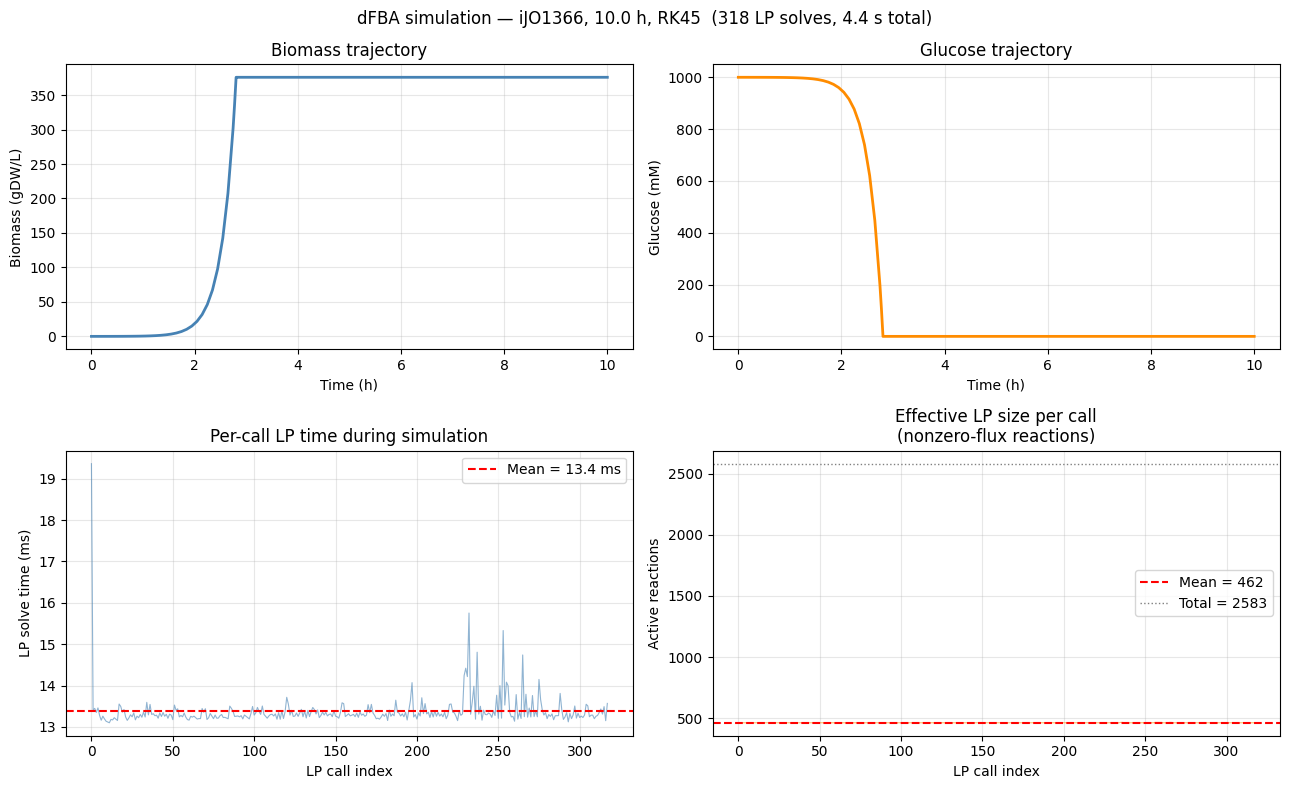

In [31]:


t_sim  = ivp_result.t
bm_sim = ivp_result.y[0]
glc_sim = ivp_result.y[1]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── Top row: biomass and glucose trajectories ──────────────────────────────
axes[0, 0].plot(t_sim, bm_sim, color='steelblue', linewidth=2)
axes[0, 0].set_xlabel('Time (h)')
axes[0, 0].set_ylabel('Biomass (gDW/L)')
axes[0, 0].set_title('Biomass trajectory')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_sim, glc_sim, color='darkorange', linewidth=2)
axes[0, 1].set_xlabel('Time (h)')
axes[0, 1].set_ylabel('Glucose (mM)')
axes[0, 1].set_title('Glucose trajectory')
axes[0, 1].grid(True, alpha=0.3)

# ── Bottom row: LP time per call and active-reaction count over simulation ─
axes[1, 0].plot(lp_sim_arr, alpha=0.6, linewidth=0.8, color='steelblue')
axes[1, 0].axhline(lp_sim_arr.mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f'Mean = {lp_sim_arr.mean():.1f} ms')
axes[1, 0].set_xlabel('LP call index')
axes[1, 0].set_ylabel('LP solve time (ms)')
axes[1, 0].set_title('Per-call LP time during simulation')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(lp_active_arr, alpha=0.6, linewidth=0.8, color='darkorange')
axes[1, 1].axhline(lp_active_arr.mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f'Mean = {lp_active_arr.mean():.0f}')
axes[1, 1].axhline(n_total_rxns, color='grey', linestyle=':', linewidth=1,
                   label=f'Total = {n_total_rxns}')
axes[1, 1].set_xlabel('LP call index')
axes[1, 1].set_ylabel('Active reactions')
axes[1, 1].set_title('Effective LP size per call\n(nonzero-flux reactions)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'dFBA simulation — iJO1366, {T_END} h, RK45  '
             f'({n_lp_sim} LP solves, {sim_time:.1f} s total)',
             fontsize=12)
plt.tight_layout()
plt.savefig('data/level2_trajectories.png', bbox_inches='tight')
plt.show()


**Commentary:** The bottom-right panel is the key addition: it shows how many reactions
carry nonzero flux at each LP call throughout the simulation. A stable flat line confirms
the active subnetwork does not shift as glucose depletes (the growth rate decreases, but
the same metabolic routes remain active). A drop near the end — when glucose is almost
exhausted — would indicate the solver is finding a qualitatively different optimal basis,
which matters for surrogate generalisation (the surrogate must handle both regimes).

The bottom-left panel shows per-call LP solve time. Correlating this with the active-reaction
count (bottom-right) reveals whether a larger or smaller active subnetwork translates into
measurably different solve times under GLPK.


## Section 4: Level 3 — Optimisation Loop Cost

The outer loop uses `scipy.optimize.minimize_scalar` (Brent's method) to find the substrate
Vmax that maximises final biomass after 10 h. Each function evaluation triggers a full dFBA
simulation — this is the realistic cost structure for bilevel dynamic metabolic optimisation
(as in Jabarivelisdeh 2021 or Espinel-Rios 2024).

The optimisation is 1D with loose tolerances (`xatol=0.5`, `maxiter=10`) purely to bound
the number of evaluations for demonstration purposes. We then extrapolate to estimate the
cost of a realistic 2D control problem requiring ~50 evaluations.


In [22]:
opt_eval_count   = [0]
active_counts_l3 = []   # mean active reactions per simulation call


def dfba_run(Vmax_val):
    # Run dFBA with given Vmax; return negative final biomass (for minimisation).
    local_active = []

    def rhs_inner(t, y):
        bm, glc = y
        glc = max(glc, 0.0)
        if glc < 1e-9:
            return [0.0, 0.0]
        mm_rate = Vmax_val * glc / (KM + glc)
        with model:
            model.reactions.get_by_id(GLC_RXN).lower_bound = -mm_rate
            sol = model.optimize()
            # Active count after timing.
            local_active.append(count_active(sol))
            if sol.status != 'optimal':
                return [0.0, 0.0]
            mu       = sol.objective_value
            flux_glc = sol.fluxes[GLC_RXN]
        return [mu * bm, flux_glc * bm]

    res = solve_ivp(
        rhs_inner,
        t_span=(0.0, T_END),
        y0=[BM0, GLC0],
        method='RK45',
        rtol=1e-4,
        atol=1e-6,
        max_step=0.1,
    )
    opt_eval_count[0] += 1
    if local_active:
        active_counts_l3.append(np.mean(local_active))
    final_bm = res.y[0, -1] if res.success else 0.0
    return -final_bm


print("Running Level 3: scalar optimisation over Vmax in [5, 20] mmol/gDW/h")
print("Objective: maximise final biomass after 10 h")
print("Method: scipy.optimize.minimize_scalar (Brent, bounded)")
print()

t_opt_start = time.time()
opt_result = minimize_scalar(
    dfba_run,
    bounds=(5.0, 20.0),
    method='bounded',
    options={'xatol': 0.5, 'maxiter': 10},
)
opt_time = time.time() - t_opt_start
n_evals  = opt_eval_count[0]
mean_active_l3 = np.mean(active_counts_l3) if active_counts_l3 else 0.0

print(f"Optimisation complete (converged: {opt_result.success})")
print()
print("Level 3 — optimisation performance:")
print(f"  Total wall-clock time:              {opt_time:.2f} s")
print(f"  Function evaluations (simulations): {n_evals}")
print(f"  Mean time per simulation:           {opt_time / n_evals:.2f} s")
print(f"  Optimal Vmax:                       {opt_result.x:.2f} mmol/gDW/h")
print(f"  Optimal final biomass:              {-opt_result.fun:.4f} gDW/L")
print()
print(f"Effective LP size during optimisation:")
print(f"  Mean active reactions per simulation: {mean_active_l3:.0f} / {n_total_rxns}  "
      f"({100 * mean_active_l3 / n_total_rxns:.1f}%)")
print(f"  Per-simulation means: {[f'{v:.0f}' for v in active_counts_l3]}")

opt_seconds = opt_time

# Extrapolation to a realistic 2D control problem
N_EXTRAP = 50
t_extrap = N_EXTRAP * (opt_time / n_evals)
print()
print("Extrapolation to a realistic outer optimisation:")
print(f"  Assumed evaluations:  {N_EXTRAP}  (2D control, similar to Jabarivelisdeh / Espinel-Rios)")
print(f"  Estimated total time: {t_extrap:.0f} s  ({t_extrap / 60:.1f} min)")
print(f"  (Basis: {opt_time / n_evals:.2f} s/simulation x {N_EXTRAP} evaluations)")


Running Level 3: scalar optimisation over Vmax in [5, 20] mmol/gDW/h
Objective: maximise final biomass after 10 h
Method: scipy.optimize.minimize_scalar (Brent, bounded)

Optimisation complete (converged: True)

Level 3 — optimisation performance:
  Total wall-clock time:              28.18 s
  Function evaluations (simulations): 8
  Mean time per simulation:           3.52 s
  Optimal Vmax:                       5.32 mmol/gDW/h
  Optimal final biomass:              12.4942 gDW/L

Effective LP size during optimisation:
  Mean active reactions per simulation: 463 / 2583  (17.9%)
  Per-simulation means: ['462', '462', '462', '462', '462', '464', '464', '464']

Extrapolation to a realistic outer optimisation:
  Assumed evaluations:  50  (2D control, similar to Jabarivelisdeh / Espinel-Rios)
  Estimated total time: 176 s  (2.9 min)
  (Basis: 3.52 s/simulation x 50 evaluations)


**Commentary:** The per-simulation active-reaction means should be consistent across all
evaluations — the same medium conditions apply regardless of the Vmax being tested.
Variation would indicate that different Vmax values push the LP into qualitatively
different optimal bases (e.g. at very low Vmax the LP might switch off some peripheral
pathways), which is relevant for how the surrogate input domain must be covered.

The extrapolated time for 50 evaluations is the practical bottleneck number: if it exceeds
several minutes, and the dominant cost is LP solves (established by Levels 1-2), the
surrogate approach is strongly motivated.


## Section 5: Decision Criteria and Recommendations

In [ ]:
def pct(n):
    return f"{100 * n / n_total_rxns:.0f}%"

print("=" * 75)
print(f"BENCHMARK SUMMARY — iJO1366 genome-scale E. coli ({ACTIVE_SOLVER.upper()} solver)")
print("=" * 75)
print(f"  {'Level':<40} {'Time':<16} {'Active rxns':<18} Notes")
print(f"  {'-'*40} {'-'*15} {'-'*17} {'-'*10}")

rows = [
    ("Level 1: Single LP solve (mean)",
     f"{single_lp_ms:.1f} ms",
     f"{mean_active_l1:.0f}/{n_total_rxns} ({pct(mean_active_l1)})",
     f"{N_TRIALS} trials"),
    ("Level 1: Single LP solve (p95)",
     f"{np.percentile(solve_times_ms,95):.1f} ms",
     f"(same)",
     ""),
    ("Level 2: Full 10-h dFBA",
     f"{sim_seconds:.1f} s",
     f"{mean_active_l2:.0f}/{n_total_rxns} ({pct(mean_active_l2)})",
     f"{n_lp_sim} LP solves"),
    ("Level 3: Scalar optimisation",
     f"{opt_seconds:.1f} s",
     f"{mean_active_l3:.0f}/{n_total_rxns} ({pct(mean_active_l3)})",
     f"{n_evals} simulations"),
    ("Level 3: Projected 50-eval opt.",
     f"~{50*(opt_seconds/n_evals):.0f} s ({50*(opt_seconds/n_evals)/60:.1f} min)",
     "(same)",
     ""),
]

for label, t_val, active_val, note in rows:
    note_str = f" [{note}]" if note else ""
    print(f"  {label:<40} {t_val:<16} {active_val:<18}{note_str}")

# ── Solver comparison summary (from Section 1.5) ──────────────────────────
if len(solver_results) > 1:
    print()
    print(f"SOLVER COMPARISON (single LP, ~{n_active_baseline} active reactions):")
    print(f"  {'-'*55}")
    _glpk_mean = solver_results.get('glpk', next(iter(solver_results.values()))).mean()
    for _s, _arr in solver_results.items():
        _tag = " <- active" if _s == ACTIVE_SOLVER else ""
        print(f"  {_s:<10}  {_arr.mean():.2f} ms  ({_glpk_mean / _arr.mean():.2f}x vs GLPK){_tag}")

print("=" * 75)

# ── Automated verdict ──────────────────────────────────────────────────────
print()
print("AUTOMATED VERDICT:")
print("-" * 75)

if single_lp_ms < 5:
    print("  Genome-scale LP is VERY FAST (< 5 ms).")
    print("  The surrogate argument based on LP cost alone is WEAK.")
    print()
    print("  Recommended next probes:")
    print("    1. Try an ME-model (ecolime): protein-allocation constraints make")
    print("       each solve 10-100x slower than plain FBA.")
    print("    2. Open more exchange reactions (rich medium) to increase effective LP size.")
    print("    3. Embed iJO1366 dFBA in a higher-dimensional control problem.")

elif single_lp_ms < 50 and sim_seconds < 5:
    print(f"  LP is in the typical genome-scale range ({single_lp_ms:.1f} ms),")
    print(f"  but a 10 h simulation completes in {sim_seconds:.1f} s.")
    print("  MARGINAL CASE — surrogate provides some benefit but argument is moderate")
    print("  unless wrapped in heavy outer optimisation.")
    print()
    print("  Recommended next probes:")
    print("    1. Extend horizon to 48 h (fed-batch) — simulation time scales ~linearly.")
    print("    2. Open more exchange reactions to increase active LP size.")
    print("    3. Profile LP vs ODE overhead breakdown.")

elif sim_seconds > 10 or opt_seconds > 60:
    print("  CLEAR COMPUTATIONAL BOTTLENECK DETECTED.")
    print(f"    - Single LP solve:    {single_lp_ms:.1f} ms")
    print(f"    - Full simulation:    {sim_seconds:.1f} s")
    print(f"    - Outer optimisation: {opt_seconds:.1f} s  ({n_evals} evals)")
    print(f"    - Active LP size:     {mean_active_l2:.0f} / {n_total_rxns} reactions ({pct(mean_active_l2)})")
    print()
    print("  A neural-network surrogate replacing LP solves directly addresses")
    print("  the inner-loop bottleneck. This is a strong thesis direction.")
    print("  Estimated surrogate speedup (assuming 0.1 ms/call):")
    print(f"    {single_lp_ms / 0.1:.0f}x per LP call")
    print(f"    {sim_seconds / (n_lp_sim * 0.1e-3):.0f}x per full simulation")

else:
    print("  INCONCLUSIVE — benchmarks are in an intermediate range.")
    print(f"    - Single LP solve:    {single_lp_ms:.1f} ms")
    print(f"    - Full simulation:    {sim_seconds:.1f} s")
    print(f"    - Outer optimisation: {opt_seconds:.1f} s")
    print()
    print("  Try a more demanding scenario:")
    print("    1. Longer horizons (24-48 h)")
    print("    2. Rich medium (more open exchange reactions)")
    print("    3. ME-models (protein allocation)")
    print("    4. Multi-substrate kinetics")

print()
print("SCALING EXPERIMENT (to run next):")
print("-" * 75)
print("  To probe how each method scales with model complexity, re-run this")
print("  notebook after opening additional exchange reactions, e.g.:")
print()
print("    # After loading the model, add:")
print("    for rxn_id in ['EX_fru_e', 'EX_ac_e', 'EX_succ_e', 'EX_for_e',")
print("                   'EX_etoh_e', 'EX_lac__D_e']:")
print("        model.reactions.get_by_id(rxn_id).lower_bound = -10.0")
print()
print("  This opens 6 additional carbon sources, increasing the active subnetwork")
print("  substantially. Compare active-reaction counts and wall-clock times to")
print("  establish how LP cost scales with effective model complexity.")

print()
print("NEXT EXPERIMENTS IF SURROGATE PATH IS VIABLE:")
print("-" * 75)
print("  A. Data generation:  Sample (substrate conc., kinetic params) -> LP solutions")
print("     Training set size scales with active-reaction count, not total reactions.")
print("  B. Surrogate design: Map state -> (mu, exchange fluxes).")
print("     Output dim = number of tracked exchange fluxes (small subset of active reactions).")
print("  C. Hybrid ODE:       Replace model.optimize() with surrogate forward pass.")
print("     Benchmark speedup directly — this is the payoff measurement.")
print("  D. Rich-medium test: Re-benchmark with larger active subnetwork to check")
print("     whether LP cost and surrogate error scale consistently.")


**Summary:** The active-reaction count column in the summary table separates *nominal model
size* (2583 reactions) from *effective LP complexity* (the subnetwork the solver actually
works on). These can differ substantially under minimal-medium conditions. The "Scaling
Experiment" block gives an explicit recipe to increase effective complexity in a controlled
way, enabling a direct comparison of how LP solve time and surrogate accuracy scale together
— which is the quantitative argument the thesis needs.
